Top 5 similar images:
1. Image Path: /home/abhinav/img_query/dataset/3.jpg, Distance: 0.0
2. Image Path: /home/abhinav/img_query/dataset/4209.jpg, Distance: 2.128049373626709
3. Image Path: /home/abhinav/img_query/dataset/3347.jpg, Distance: 3.3712151050567627
4. Image Path: /home/abhinav/img_query/dataset/634.jpg, Distance: 4.060237407684326
5. Image Path: /home/abhinav/img_query/dataset/4647.jpg, Distance: 5.060173034667969


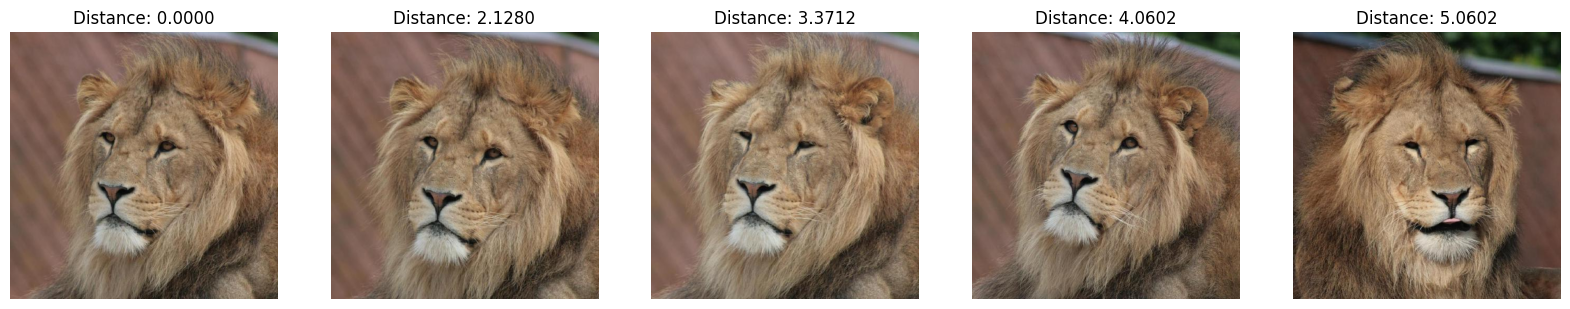

In [1]:
#--SWIN - Unet 
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import swin_t, Swin_T_Weights
from PIL import Image
import faiss
import numpy as np
import os
import matplotlib.pyplot as plt


#--using the encoder of pre trained swin T from pytorch 
class SwinEncoder(nn.Module):
    def __init__(self):
        super(SwinEncoder, self).__init__()
        self.swin = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1)
        self.swin_features = nn.Sequential(*list(self.swin.children())[:-1])

    def forward(self, x):
        return self.swin_features(x)

class UNetDecoder(nn.Module): #--using decoder of Unet 
    def __init__(self, input_channels, output_channels):
        super(UNetDecoder, self).__init__()
        self.upconv1 = nn.ConvTranspose2d(input_channels, 512, kernel_size=2, stride=2)
        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(64, output_channels, kernel_size=1)

    def forward(self, x):
        x = nn.ReLU()(self.upconv1(x))
        x = nn.ReLU()(self.upconv2(x))
        x = nn.ReLU()(self.upconv3(x))
        x = nn.ReLU()(self.upconv4(x))
        return self.final_conv(x)

class SwinUNet(nn.Module): # encoder and decoder inherited by the above classes 
    def __init__(self, num_classes=1):
        super(SwinUNet, self).__init__()
        self.encoder = SwinEncoder()
        self.decoder = UNetDecoder(input_channels=768, output_channels=num_classes)

    def forward(self, x):
        features = self.encoder(x)
        x = features.view(features.size(0), 768, 1, 1)
        x = self.decoder(x)
        return x, features

def preprocess_image(image):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])
    return preprocess(image).unsqueeze(0)

def build_faiss_index(feature_list):
    dimension = feature_list[0].shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(np.vstack(feature_list))
    return index

# Instantiate the model and set it to evaluation mode
num_classes = 1
model = SwinUNet(num_classes=num_classes)
model.eval()

# Move model to GPU if available (makes the process really fast! ) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Process dataset and extract features
dataset_path = "/home/abhinav/img_query/dataset"
image_paths = [os.path.join(dataset_path, fname) for fname in os.listdir(dataset_path) if fname.lower().endswith(( '.jpg'))]

# extracting features of each images in the form of embeddings
features = []
for image_path in image_paths:
    image = Image.open(image_path).convert('RGB')
    image_tensor = preprocess_image(image).to(device)
    with torch.no_grad():
        _, feature = model(image_tensor)
    features.append(feature.flatten(1).cpu().numpy())

# Build FAISS index
faiss_index = build_faiss_index(features)

def query_faiss_index(index, query_feature, top_k=5):
    distances, indices = index.search(query_feature, top_k)
    return distances, indices

# Query the FAISS index with a new image as per your choice
query_image_path = "/home/abhinav/img_query/dataset/3.jpg"
query_image = Image.open(query_image_path).convert('RGB')
query_tensor = preprocess_image(query_image).to(device)
with torch.no_grad():
    _, query_feature = model(query_tensor)

# Reshape and search 
query_feature = query_feature.flatten(1).cpu().numpy()
distances, indices = query_faiss_index(faiss_index, query_feature, top_k=5)

# Display top 5 similar images
print("Top 5 similar images:")
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (distance, index) in enumerate(zip(distances[0], indices[0])):
    print(f"{i + 1}. Image Path: {image_paths[index]}, Distance: {distance}")
    image = Image.open(image_paths[index]).convert('RGB')
    axes[i].imshow(image)
    axes[i].axis('off')
    axes[i].set_title(f"Distance: {distance:.4f}")
plt.show()